In [1]:
import tensorflow as tf

# Allow GPU memory to grow gradually
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

# Check available RAM
import psutil
ram_gb = psutil.virtual_memory().total / 1e9
print(f"Available RAM: {ram_gb:.1f} GB")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

GPU memory growth enabled for 1 GPU(s)
Available RAM: 54.8 GB
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import os
from google.colab import drive

# Ensure the mount point is clean before attempting to mount.
# This forcefully removes any existing /content/drive directory.
if os.path.exists('/content/drive'):
    !rm -rf /content/drive
    print("Removed existing /content/drive directory.")

drive.mount('/content/drive', force_remount=True)

Removed existing /content/drive directory.
Mounted at /content/drive


In [6]:
!ls /content/drive/MyDrive/deepfake_v2/deepfake_processed

metadata.json	    X_train_seq.npy    y_test_seq.npy	   y_val_seq.npy
X_test_frames.npy   X_val_frames.npy   y_train_frames.npy
X_test_seq.npy	    X_val_seq.npy      y_train_seq.npy
X_train_frames.npy  y_test_frames.npy  y_val_frames.npy


In [13]:
import tensorflow as tf
import numpy as np
import json, os, gc
from tensorflow.keras.applications import MobileNetV2, Xception
from tensorflow.keras.layers import (
    Input, Dense, GRU, Bidirectional,
    Conv2D, GlobalAveragePooling2D,
    TimeDistributed, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report)

DATA = '/content/drive/MyDrive/deepfake_v2/deepfake_processed'
SAVE = '/content/drive/MyDrive/deepfake_v2/deepfake_models'
os.makedirs(SAVE, exist_ok=True)

# ── Load data ──────────────────────────────────────────
print("Loading frame-level data...")
X_train_f = np.load(f'{DATA}/X_train_frames.npy')
X_val_f   = np.load(f'{DATA}/X_val_frames.npy')
X_test_f  = np.load(f'{DATA}/X_test_frames.npy')
y_train_f = np.load(f'{DATA}/y_train_frames.npy')
y_val_f   = np.load(f'{DATA}/y_val_frames.npy')
y_test_f  = np.load(f'{DATA}/y_test_frames.npy')

print(f"Train frames : {X_train_f.shape} "
      f"real={sum(y_train_f==0)} fake={sum(y_train_f==1)}")
print(f"Val frames   : {X_val_f.shape}")
print(f"Test frames  : {X_test_f.shape}")

print("\nLoading sequence data...")
X_train_s = np.load(f'{DATA}/X_train_seq.npy')
X_val_s   = np.load(f'{DATA}/X_val_seq.npy')
X_test_s  = np.load(f'{DATA}/X_test_seq.npy')
y_train_s = np.load(f'{DATA}/y_train_seq.npy')
y_val_s   = np.load(f'{DATA}/y_val_seq.npy')
y_test_s  = np.load(f'{DATA}/y_test_seq.npy')

print(f"Train seq    : {X_train_s.shape} "
      f"real={sum(y_train_s==0)} fake={sum(y_train_s==1)}")
print(f"Val seq      : {X_val_s.shape}")
print(f"Test seq     : {X_test_s.shape}")

# ── Binary labels for evaluation ──────────────────────
y_test_bin  = (y_test_f  > 0).astype(int)
y_test_sbin = (y_test_s  > 0).astype(int)

# ── CBAM ──────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable()
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
    def build(self, input_shape):
        ch = input_shape[-1]
        self.fc1 = Dense(ch // self.ratio, activation='relu')
        self.fc2 = Dense(ch, activation='sigmoid')
    def call(self, x):
        avg = tf.reduce_mean(x, axis=[1,2], keepdims=True)
        mx  = tf.reduce_max(x,  axis=[1,2], keepdims=True)
        return x * (self.fc2(self.fc1(avg)) +
                    self.fc2(self.fc1(mx)))

@tf.keras.utils.register_keras_serializable()
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.conv = Conv2D(1, 7, padding='same',
                           activation='sigmoid')
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x,  axis=-1, keepdims=True)
        return x * self.conv(tf.concat([avg, mx], axis=-1))

def cbam_block(x):
    x = ChannelAttention()(x)
    x = SpatialAttention()(x)
    return x

# ── Callbacks ──────────────────────────────────────────
def get_callbacks(name):
    return [
        EarlyStopping(patience=5,
                      restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=3,
                          verbose=1),
        ModelCheckpoint(
            f'{SAVE}/{name}_best.keras',
            save_best_only=True, verbose=1)
    ]

# ── Evaluation ─────────────────────────────────────────
def evaluate(model, name, X_te, y_bin):
    y_prob = model.predict(X_te, verbose=0)
    if y_prob.shape[-1] > 1:
        y_prob_fake = 1.0 - y_prob[:, 0]
    else:
        y_prob_fake = y_prob.flatten()
    y_pred = (y_prob_fake > 0.5).astype(int)
    auc  = roc_auc_score(y_bin, y_prob_fake)
    f1  = f1_score(y_bin, y_pred)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(classification_report(y_bin, y_pred,
          target_names=['Real','Fake']))
    return float(auc), float(f1)

# ════════════════════════════════════════════════════════
# CONDITION A — Xception Baseline (frame-level)
# ════════════════════════════════════════════════════════
print("\n" + "="*50)
print("CONDITION A — Xception Baseline")
print("="*50)

base_a = Xception(weights='imagenet',
                  include_top=False,
                  input_shape=(224,224,3))
base_a.trainable = False

x   = base_a.output
x   = GlobalAveragePooling2D()(x)
x   = Dense(128, activation='relu')(x)
x   = Dropout(0.3)(x)
out = Dense(2, activation='softmax')(x)
model_a = Model(base_a.input, out,
                name='Condition_A_Xception')

model_a.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

model_a.fit(
    X_train_f, y_train_f,
    validation_data=(X_val_f, y_val_f),
    epochs=20, batch_size=32,
    callbacks=get_callbacks('condition_a'))

auc_a, f1_a = evaluate(
    model_a, "Condition A — Xception",
    X_test_f, y_test_bin)

model_a.save(f'{SAVE}/condition_a_final.keras')

# Free memory before next model
del model_a, base_a
tf.keras.backend.clear_session()
gc.collect()
print("Condition A memory freed")

# ════════════════════════════════════════════════════════
# CONDITION B — MobileNetV2+CBAM+GRU Frozen
# ════════════════════════════════════════════════════════
print("\n" + "="*50)
print("CONDITION B — MobileNetV2+CBAM+GRU Frozen")
print("Backbone NOT fine-tuned — measures domain shift")
print("="*50)

def build_frame_encoder(fine_tune_layers=0):
    base = MobileNetV2(weights='imagenet',
                       include_top=False,
                       input_shape=(224,224,3))
    if fine_tune_layers == 0:
        base.trainable = False
    else:
        for layer in base.layers[:-fine_tune_layers]:
            layer.trainable = False
        for layer in base.layers[-fine_tune_layers:]:
            layer.trainable = True

    inp = Input(shape=(224,224,3))
    x   = base(inp)
    x   = cbam_block(x)
    x   = GlobalAveragePooling2D()(x)
    return Model(inp, x, name='frame_encoder')

def build_sequence_model(encoder, name):
    seq_inp = Input(shape=(15,224,224,3))
    feats   = TimeDistributed(encoder)(seq_inp)
    x       = Bidirectional(
        GRU(64, return_sequences=True))(feats)
    x       = Bidirectional(GRU(32))(x)
    x       = Dense(64, activation='relu')(x)
    x       = Dropout(0.4)(x)
    out     = Dense(2, activation='softmax')(x)
    return Model(seq_inp, out, name=name)

# Condition B — frozen backbone
encoder_b = build_frame_encoder(fine_tune_layers=0)
model_b   = build_sequence_model(
    encoder_b, 'Condition_B_Frozen')

model_b.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
model_b.summary()

model_b.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=20, batch_size=4,
    callbacks=get_callbacks('condition_b'))

auc_b, f1_b = evaluate(
    model_b, "Condition B — MobileNetV2+CBAM+GRU Frozen",
    X_test_s, y_test_sbin)

model_b.save(f'{SAVE}/condition_b_final.keras')

# Free memory
del model_b, encoder_b
tf.keras.backend.clear_session()
gc.collect()
print("Condition B memory freed")

# ════════════════════════════════════════════════════════
# CONDITION C — MobileNetV2+CBAM+GRU Fine-tuned
# YOUR PROPOSED MODEL
# ════════════════════════════════════════════════════════
print("\n" + "="*50)
print("CONDITION C — MobileNetV2+CBAM+GRU Fine-tuned")
print("Last 30 backbone layers fine-tuned on SL data")
print("="*50)

encoder_c = build_frame_encoder(fine_tune_layers=30)
model_c   = build_sequence_model(
    encoder_c, 'Condition_C_Finetuned')

model_c.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
model_c.summary()

model_c.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=30, batch_size=4,
    callbacks=get_callbacks('condition_c'))

auc_c, f1_c = evaluate(
    model_c, "Condition C — MobileNetV2+CBAM+GRU Fine-tuned",
    X_test_s, y_test_sbin)

model_c.save(f'{SAVE}/condition_c_final.keras')

# ── Export TFLite ──────────────────────────────────────
print("\nExporting TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model_c)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite = converter.convert()

with open(f'{SAVE}/condition_c_final.tflite', 'wb') as f:
    f.write(tflite)
print(f"TFLite size: {len(tflite)/1e6:.1f} MB")

# ── Final Results ──────────────────────────────────────
gap = auc_c - auc_b

results = {
    'condition_a': {
        'model': 'Xception baseline',
        'fine_tuned': False,
        'data_type': 'frame_level',
        'AUC': auc_a, 'F1': f1_a},
    'condition_b': {
        'model': 'MobileNetV2+CBAM+BiGRU frozen',
        'fine_tuned': False,
        'data_type': 'sequence_15frames',
        'AUC': auc_b, 'F1': f1_b},
    'condition_c': {
        'model': 'MobileNetV2+CBAM+BiGRU fine-tuned',
        'fine_tuned': True,
        'data_type': 'sequence_15frames',
        'AUC': auc_c, 'F1': f1_c},
    'domain_shift_gap_AUC': round(gap, 4),
    'interpretation': (
        f'Fine-tuning on Sri Lankan content improved '
        f'AUC by {gap:+.4f} over frozen baseline. '
        f'First empirical domain shift measurement '
        f'for Sinhala/Tamil deepfake detection.')
}

with open(f'{SAVE}/comparison_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*55}")
print(f"ALL CONDITIONS COMPLETE")
print(f"{'='*55}")
print(f"Condition A  AUC={auc_a:.4f}  F1={f1_a:.4f}  (Xception)")
print(f"Condition B  AUC={auc_b:.4f}  F1={f1_b:.4f}  (Frozen)")
print(f"Condition C  AUC={auc_c:.4f}  F1={f1_c:.4f}  (Fine-tuned)")
print(f"Domain Shift Gap (C-B): {gap:+.4f}")
print(f"\nSaved to: {SAVE}")
print(f"Download condition_c_final.tflite for deployment")

Loading frame-level data...
Train frames : (2665, 224, 224, 3) real=960 fake=1705
Val frames   : (570, 224, 224, 3)
Test frames  : (585, 224, 224, 3)

Loading sequence data...
Train seq    : (176, 15, 224, 224, 3) real=64 fake=112
Val seq      : (38, 15, 224, 224, 3)
Test seq     : (39, 15, 224, 224, 3)

CONDITION A — Xception Baseline
Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.6487 - loss: 0.6370
Epoch 1: val_loss improved from None to 0.63552, saving model to /content/drive/MyDrive/deepfake_v2/deepfake_models/condition_a_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/deepfake_v2/deepfake_models/condition_a_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 364ms/step - accuracy: 0.6882 - loss: 0.5936 - val_accuracy: 0.6316 - val_loss: 0.6355 - learning_rate: 1.0000e-04
Epoch 2/20
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7647 - loss: 0.5077
Epoch 2: val_loss improved from 0.63552 to 0.62427, saving model to /content/drive/MyDrive/deepf

Model: "Condition_B_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 15, 1280)       │     2,669,123 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │       516,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,221,381 (12.29 MB)

 Trainable params: 963,397 (3.68 MB)

...

 Total params: 3,221,381 (12.29 MB)

 Trainable params: 2,489,797 (9.50 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.5866 - loss: 0.6544
Epoch 1: val_loss improved from None to 0.54895, saving model to /content/drive/MyDrive/deepfake_v2/deepfake_models/condition_c_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/deepfake_v2/deepfake_models/condition_c_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 119s 782ms/step - accuracy: 0.6364 - loss: 0.6424 - val_accuracy: 0.6316 - val_loss: 0.5489 - learning_rate: 1.0000e-04
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.7424 - loss: 0.5101
Epoch 2: val_loss improved from 0.54895 to 0.50018, saving model to /content/drive/MyDrive/deepfake_v2/deepfake_models/condition_c_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/deepfake_v2/deepfake_models/condition_c_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step - accuracy: 0.7784 - loss: 0.4851 - val_accuracy: 0.7895 - val_loss: 0.5002 - learning_rate: 1.0000e-04
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(fused["CudnnRNNV3:", "Condition_C_Finetuned_1/bidirectional_1/backward_gru_1/CudnnRNNV3@__inference_function_1023317"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_1024456"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.CudnnRNNV3' op is neither a custom op nor a flex op
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_1024456"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(fused["CudnnRNNV3:", "Condition_C_Finetuned_1/bidirectional_1/backward_gru_1/CudnnRNNV3@__inference_function_1023317"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_


Condition A — Xception Baseline
Accuracy : 0.5949
AUC-ROC  : 0.5271
F1-Score : 0.6877

Classification Report:
              precision    recall  f1-score   support

        Real       0.43      0.41      0.42       210
        Fake       0.68      0.70      0.69       375

    accuracy                           0.59       585
   macro avg       0.56      0.56      0.56       585
weighted avg       0.59      0.59      0.59       585

Confusion Matrix:
[[ 87 123]
 [114 261]]


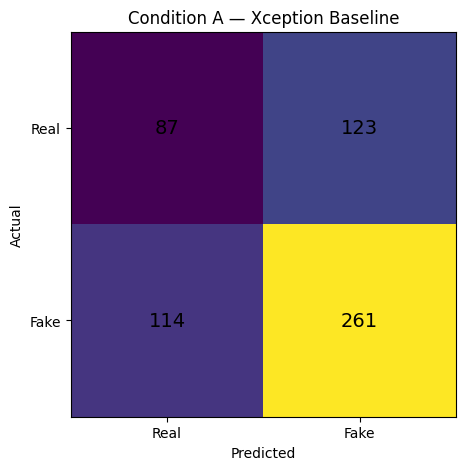


Condition B — MobileNetV2+CBAM+BiGRU Frozen
Accuracy : 0.6410
AUC-ROC  : 0.6514
F1-Score : 0.7407

Classification Report:
              precision    recall  f1-score   support

        Real       0.50      0.36      0.42        14
        Fake       0.69      0.80      0.74        25

    accuracy                           0.64        39
   macro avg       0.59      0.58      0.58        39
weighted avg       0.62      0.64      0.62        39

Confusion Matrix:
[[ 5  9]
 [ 5 20]]


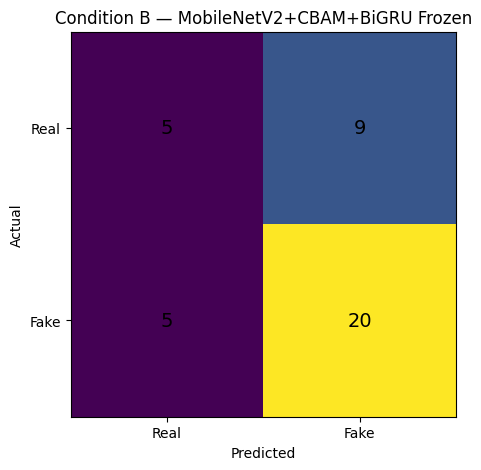


Condition C — MobileNetV2+CBAM+BiGRU Fine-tuned
Accuracy : 0.6923
AUC-ROC  : 0.7743
F1-Score : 0.7857

Classification Report:
              precision    recall  f1-score   support

        Real       0.62      0.36      0.45        14
        Fake       0.71      0.88      0.79        25

    accuracy                           0.69        39
   macro avg       0.67      0.62      0.62        39
weighted avg       0.68      0.69      0.67        39

Confusion Matrix:
[[ 5  9]
 [ 3 22]]


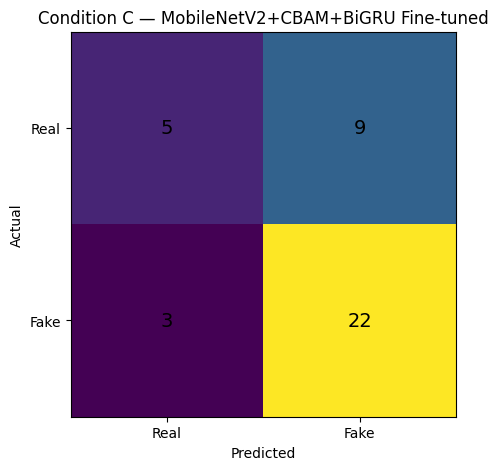


FINAL MODEL COMPARISON
Condition A  | Accuracy=0.5949 | AUC=0.5271 | F1=0.6877
Condition B  | Accuracy=0.6410 | AUC=0.6514 | F1=0.7407
Condition C  | Accuracy=0.6923 | AUC=0.7743 | F1=0.7857

Domain Shift Gap (C - B): +0.1229

Interpretation:
Fine-tuning on Sri Lankan Sinhala/Tamil deepfake data improved model generalization over the frozen baseline.


In [14]:
import tensorflow as tf
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)

import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate(model, name, X_te, y_te):

    # ---------------------------------
    # Predict probabilities
    # ---------------------------------
    y_prob = model.predict(X_te, verbose=0)

    # ---------------------------------
    # Handle softmax / sigmoid
    # ---------------------------------
    if y_prob.shape[-1] > 1:
        y_prob_fake = 1.0 - y_prob[:, 0]
    else:
        y_prob_fake = y_prob.flatten()

    # ---------------------------------
    # Convert labels to binary
    # real=0
    # partial/full fake=1
    # ---------------------------------
    y_bin = (y_te > 0).astype(int)

    # ---------------------------------
    # Final predictions
    # ---------------------------------
    y_pred = (y_prob_fake > 0.5).astype(int)

    # ---------------------------------
    # Metrics
    # ---------------------------------
    acc = accuracy_score(y_bin, y_pred)
    auc = roc_auc_score(y_bin, y_prob_fake)
    f1  = f1_score(y_bin, y_pred)

    # ---------------------------------
    # Print results
    # ---------------------------------
    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {acc:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_bin,
        y_pred,
        target_names=['Real', 'Fake']
    ))

    # ---------------------------------
    # Confusion Matrix
    # ---------------------------------
    cm = confusion_matrix(y_bin, y_pred)

    print("Confusion Matrix:")
    print(cm)

    # ---------------------------------
    # Plot confusion matrix
    # ---------------------------------
    plt.figure(figsize=(5,5))

    plt.imshow(cm)

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks([0,1], ['Real','Fake'])
    plt.yticks([0,1], ['Real','Fake'])

    for i in range(2):
        for j in range(2):
            plt.text(
                j, i,
                str(cm[i,j]),
                ha='center',
                va='center',
                fontsize=14
            )

    plt.show()

    return acc, auc, f1


# =========================================================
# EVALUATE CONDITION A
# =========================================================

# Load model A
model_a = tf.keras.models.load_model(f'{SAVE}/condition_a_final.keras')

acc_a, auc_a, f1_a = evaluate(
    model_a,
    "Condition A — Xception Baseline",
    X_test_f,
    y_test_f
)


# =========================================================
# EVALUATE CONDITION B
# =========================================================

# Load model B
model_b = tf.keras.models.load_model(f'{SAVE}/condition_b_final.keras')

acc_b, auc_b, f1_b = evaluate(
    model_b,
    "Condition B — MobileNetV2+CBAM+BiGRU Frozen",
    X_test_s,
    y_test_s
)


# =========================================================
# EVALUATE CONDITION C
# =========================================================

# Load model C
model_c = tf.keras.models.load_model(f'{SAVE}/condition_c_final.keras')

acc_c, auc_c, f1_c = evaluate(
    model_c,
    "Condition C — MobileNetV2+CBAM+BiGRU Fine-tuned",
    X_test_s,
    y_test_s
)


# =========================================================
# FINAL COMPARISON
# =========================================================

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(f"Condition A  | Accuracy={acc_a:.4f} | AUC={auc_a:.4f} | F1={f1_a:.4f}")
print(f"Condition B  | Accuracy={acc_b:.4f} | AUC={auc_b:.4f} | F1={f1_b:.4f}")
print(f"Condition C  | Accuracy={acc_c:.4f} | AUC={auc_c:.4f} | F1={f1_c:.4f}")

gap = auc_c - auc_b

print("\nDomain Shift Gap (C - B): "
      f"{gap:+.4f}")

print("\nInterpretation:")
print(
    "Fine-tuning on Sri Lankan Sinhala/Tamil "
    "deepfake data improved model "
    "generalization over the frozen baseline."
)